In [ ]:
# Importo le librerie necessarie all'inizio del notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

# Carico il dataset direttamente tramite URL pubblico
url_dataset = "https://proai-datasets.s3.eu-west-3.amazonaws.com/aviation-accidents.csv"

try:
    df = pd.read_csv(url_dataset)
    print("Dataset caricato. Dimensioni:", df.shape)
    display(df.head(5))
except Exception as e:
    print("Errore nel caricamento:", e)

Dataset caricato. Dimensioni: (23967, 9)


,date,type,registration,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,T-1206,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
1,date unk.,Antonov An-12B,T-1204,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
2,date unk.,Antonov An-12B,T-1201,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
3,date unk.,Antonov An-12BK,NaN,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,unknown
4,date unk.,Antonov An-12BP,CCCP-11815,Soviet AF,0,Massawa Airport ...,Eritrea,A1,unknown


In [ ]:
# Esplorazione iniziale del dataframe
print("Struttura dei dati:")
df.info()

print("\nValori mancanti:")
print(df.isnull().sum())


# Pulizia colonna 'fatalities' utlizzando la funzione eval
def pulisci_morti(valore):
    if pd.isna(valore): return 0
    try: return eval(str(valore))
    except: return np.nan

df['fatalities'] = df['fatalities'].apply(pulisci_morti)
df['fatalities'] = pd.to_numeric(df['fatalities'], errors='coerce').fillna(0)

# Estraggo l'anno pulito e converto le date gestendo i formati anomali
df['year_extracted'] = df['date'].str.extract(r'(\d{4})')
df['year_extracted'] = pd.to_numeric(df['year_extracted'], errors='coerce')
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')

#Rimuovo i valori 'unknown' da tutto il dataset

df = df[df['operator'].str.lower() != 'unknown']

df = df[~df['country'].str.lower().str.contains('unknown', na=False)]

Struttura dei dati:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23967 entries, 0 to 23966
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          23967 non-null  object
 1   type          23967 non-null  object
 2   registration  22419 non-null  object
 3   operator      23963 non-null  object
 4   fatalities    20029 non-null  object
 5   location      23019 non-null  object
 6   country       23967 non-null  object
 7   cat           23967 non-null  object
 8   year          23967 non-null  object
dtypes: object(9)
memory usage: 1.6+ MB

Valori mancanti:
date               0
type               0
registration    1548
operator           4
fatalities      3938
location         948
country            0
cat                0
year               0
dtype: int64


/tmp/ipykernel_6445/4097866201.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')


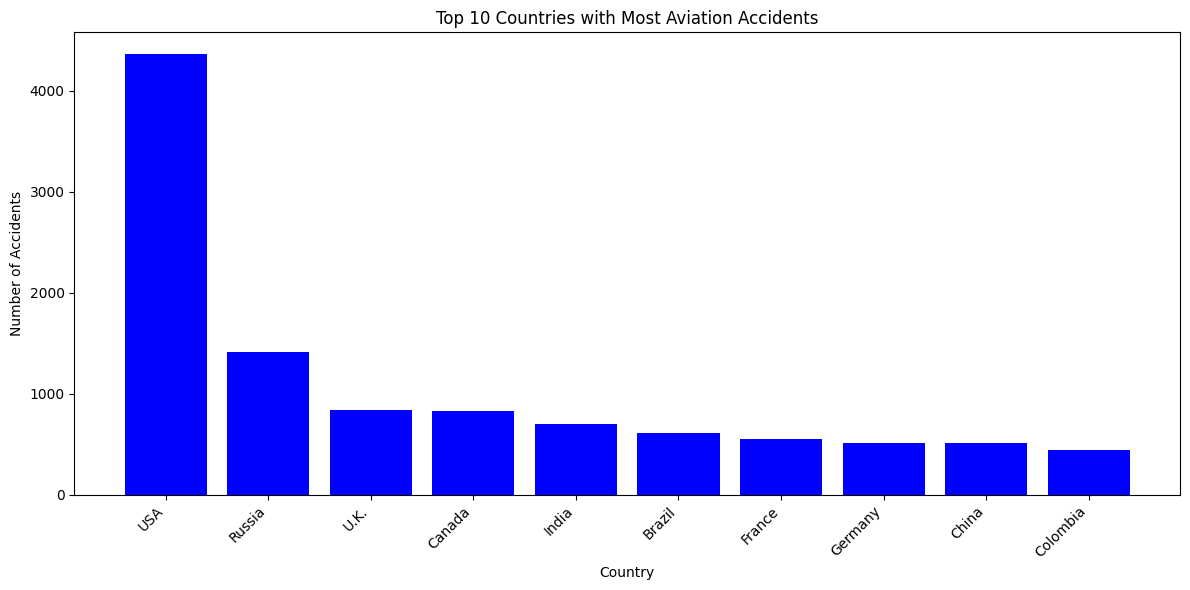

In [ ]:
# Ordino i paesi per numero di incidenti in ordine decrescente
country_accidents = df['country'].value_counts().sort_values(ascending=False)
top_10_countries = country_accidents.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_countries.index, top_10_countries.values, color='blue')
plt.xlabel('Country')
plt.ylabel('Number of Accidents')
plt.title('Top 10 Countries with Most Aviation Accidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Ranking of incidents by day of the week (most to least):
Friday       3563
Thursday     3382
Wednesday    3358
Tuesday      3315
Monday       3180
Saturday     3069
Sunday       2656


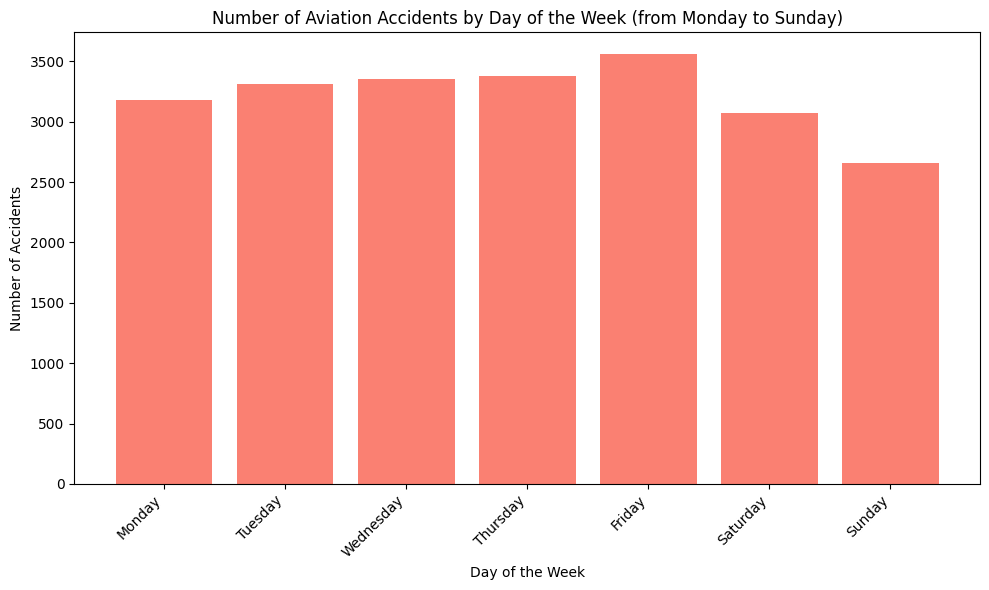

In [ ]:
# Estraggo il giorno della settimana e definisco l'ordine desiderato
df['day_of_week'] = df['date_parsed'].dt.day_name()
accidents_by_day = df['day_of_week'].value_counts()

print("Ranking of incidents by day of the week (most to least):")
print(accidents_by_day.to_string(header=False))

# Riordino la serie per il grafico
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
accidents_by_day_ordered = accidents_by_day.reindex(day_order)

plt.figure(figsize=(10, 6))
plt.bar(accidents_by_day_ordered.index, accidents_by_day_ordered.values, color='salmon')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Accidents')
plt.title('Number of Aviation Accidents by Day of the Week (from Monday to Sunday)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 10 Operatori più sicuri (minimo 20 incidenti):
                    totale_incidenti  totale_morti  morti_per_incidente
operator                                                               
Southwest Airlines                26             2             0.076923
ZUA                               32             4             0.125000
Private                           53            47             0.886792
FAA                               20            18             0.900000
private                          296           272             0.918919
Aeroflot, MAGON                   28            42             1.500000
Dutch Navy                        31            63             2.032258
USAAF                           2170          4503             2.075115
Air Union                         20            43             2.150000
Imperial Airways                  39            85             2.179487


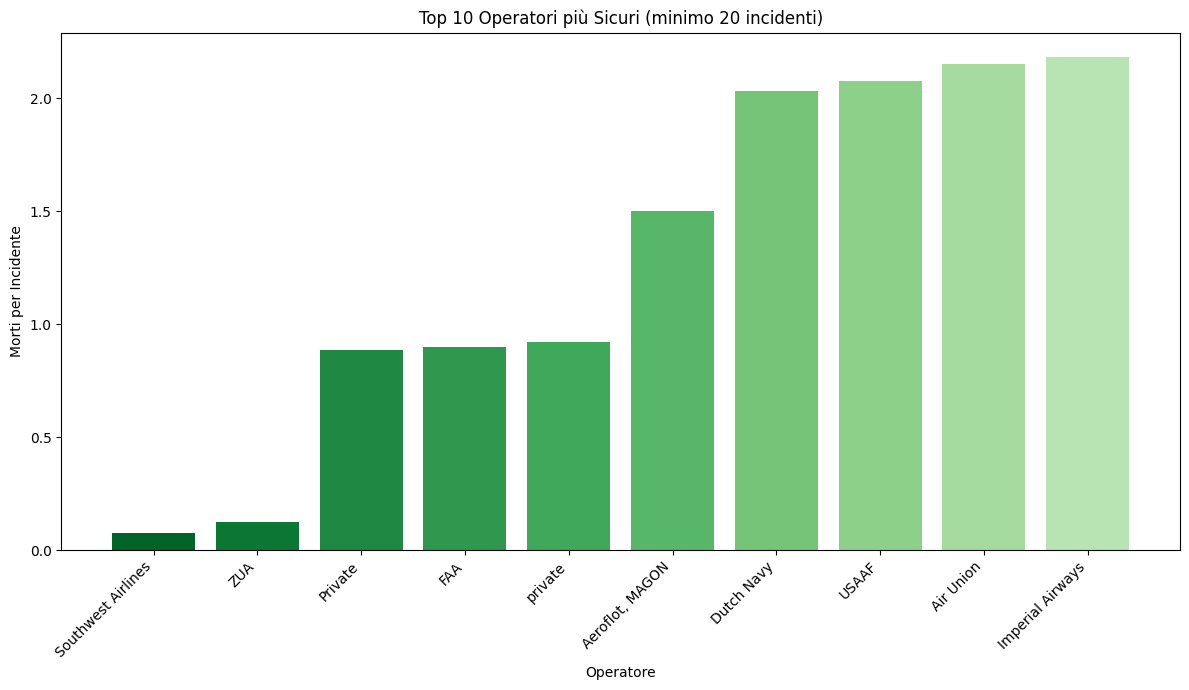

In [ ]:


# Calcolo totale incidenti e morti per ogni operatore
analisi_operatori = df.groupby('operator').agg(
    totale_incidenti=('date', 'count'),
    totale_morti=('fatalities', 'sum')
)

# Filtro solo gli operatori con almeno 20 incidenti per avere un campione statistico rilevante
operatori_rilevanti = analisi_operatori[analisi_operatori['totale_incidenti'] >= 20].copy()

# Calcolo il rapporto morti per singolo incidente
operatori_rilevanti['morti_per_incidente'] = operatori_rilevanti['totale_morti'] / operatori_rilevanti['totale_incidenti']

# Ordino la classifica per trovare i più sicuri
operatori_sicuri = operatori_rilevanti.sort_values('morti_per_incidente', ascending=True)

print("Top 10 Operatori più sicuri (minimo 20 incidenti):")
print(operatori_sicuri.head(10))

# Genero un gradiente di colori dal verde scuro al verde chiaro per le 10 barre

mappa_colori = plt.get_cmap('Greens')
colori_sfumati = mappa_colori(np.linspace(0.9, 0.3, len(operatori_sicuri.head(10))))

# Creo il grafico a barre per i top 10 operatori più sicuri
plt.figure(figsize=(12, 7))
plt.bar(operatori_sicuri.head(10).index,
        operatori_sicuri['morti_per_incidente'].head(10),
        color=colori_sfumati)  # Utilizzo i colori sfumati
plt.xlabel('Operatore')
plt.ylabel('Morti per Incidente')
plt.title('Top 10 Operatori più Sicuri (minimo 20 incidenti)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Classifica dei decessi per tipo di velivolo (top 10):
type
Douglas C-47A (DC-3)        5770
Douglas C-47 (DC-3)         2636
Douglas C-47B (DC-3)        1992
Boeing 767-223ER            1692
Tupolev Tu-154M             1600
DC-9-32                     1441
Ilyushin Il-18V             1356
Lockheed C-130H Hercules    1271
Antonov An-26               1246
Junkers Ju-52/3m            1106


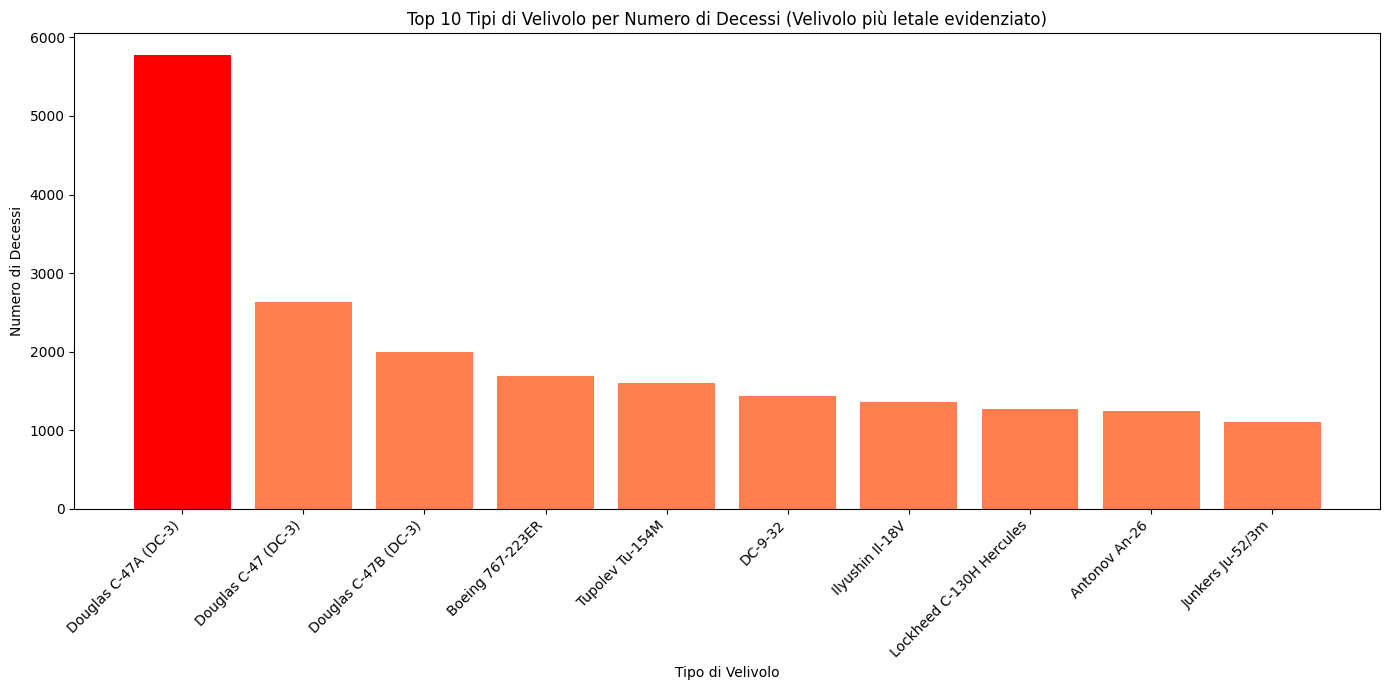


Il velivolo che ha causato più morti è: Douglas C-47A (DC-3)


In [ ]:
# Raggruppo per tipo di velivolo e ordino per decessi totali
fatalities_by_aircraft_type = df.groupby('type')['fatalities'].sum().sort_values(ascending=False)

print("Classifica dei decessi per tipo di velivolo (top 10):")
print(fatalities_by_aircraft_type.head(10).to_string())

top_10_fatalities_by_type = fatalities_by_aircraft_type.head(10)
most_fatal_aircraft = top_10_fatalities_by_type.index[0]

# Creo la lista di colori evidenziando in rosso il velivolo più letale
colors = ['coral' if aircraft != most_fatal_aircraft else 'red' for aircraft in top_10_fatalities_by_type.index]

plt.figure(figsize=(14, 7))
plt.bar(top_10_fatalities_by_type.index, top_10_fatalities_by_type.values, color=colors)
plt.xlabel('Tipo di Velivolo')
plt.ylabel('Numero di Decessi')
plt.title('Top 10 Tipi di Velivolo per Numero di Decessi (Velivolo più letale evidenziato)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nIl velivolo che ha causato più morti è: {most_fatal_aircraft}")

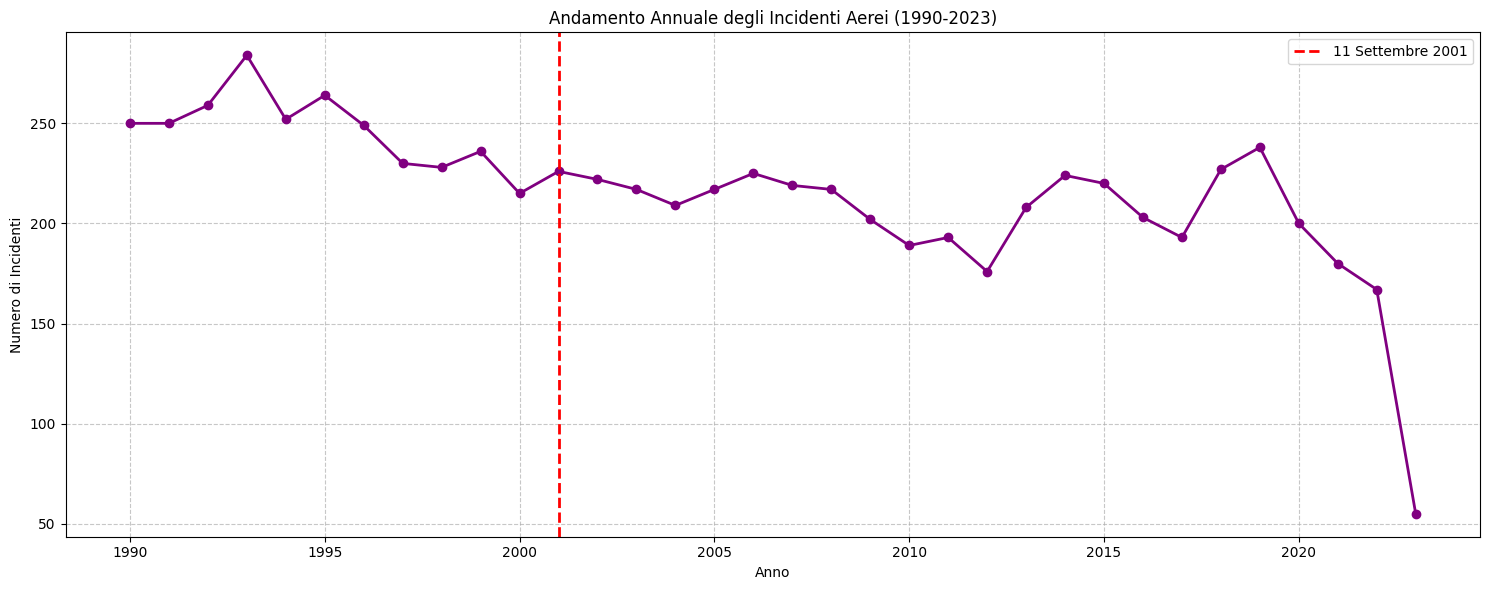

In [ ]:
# Filtro i dati a partire dal 1990
df_recent = df[df['year_extracted'] >= 1990]
incidenti_per_anno = df_recent.groupby('year_extracted').size()

# Grafico andamento temporale
plt.figure(figsize=(15, 6))
plt.plot(incidenti_per_anno.index, incidenti_per_anno.values, color='purple', marker='o', linewidth=2)
plt.axvline(x=2001, color='red', linestyle='--', linewidth=2, label='11 Settembre 2001')

plt.title("Andamento Annuale degli Incidenti Aerei (1990-2023)")
plt.xlabel("Anno")
plt.ylabel("Numero di Incidenti")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Mappa globale degli incidenti
dati_mappa = df['country'].value_counts().reset_index()
dati_mappa.columns = ['nazione', 'incidenti']

# Allineo i nomi di alcuni stati allo standard riconosciuto da Plotly
mappa_correzioni = {
    'USA': 'United States',
    'U.K.': 'United Kingdom',
    'Russia': 'Russian Federation',
    'S. Africa': 'South Africa',
    'Korea, South': 'South Korea',
    'Korea, North': 'North Korea',
    'Democratic Republic of Congo': 'Democratic Republic of the Congo',
    'Bosnia-Herzegovina': 'Bosnia and Herzegovina'
}
dati_mappa['nazione'] = dati_mappa['nazione'].replace(mappa_correzioni)

fig = px.choropleth(dati_mappa,
                    locations="nazione",
                    locationmode="country names",
                    color="incidenti",
                    title="Mappa Globale degli Incidenti Aerei per Nazione",
                    color_continuous_scale="Reds")

fig.show()